In [6]:
import numpy as np
from PIL import Image
from pathlib import Path
path = "./Dataset"
target_size = (224, 224)

In [18]:
insect_classes = ["butterfly", "dragonfly", "grasshopper", "ladybird", "mosquito"]
dataset = []
labels = []
for insect_class in insect_classes:
    class_path = Path(path) / insect_class
    for img_path in class_path.glob("*.jpg"):
        img = Image.open(img_path).convert("RGB")
        img = img.resize(target_size)
        dataset.append(np.array(img))
        labels.append(insect_class)
dataset = np.array(dataset)
labels = np.array(labels)

In [19]:
dataset.shape, labels.shape

((4449, 224, 224, 3), (4449,))

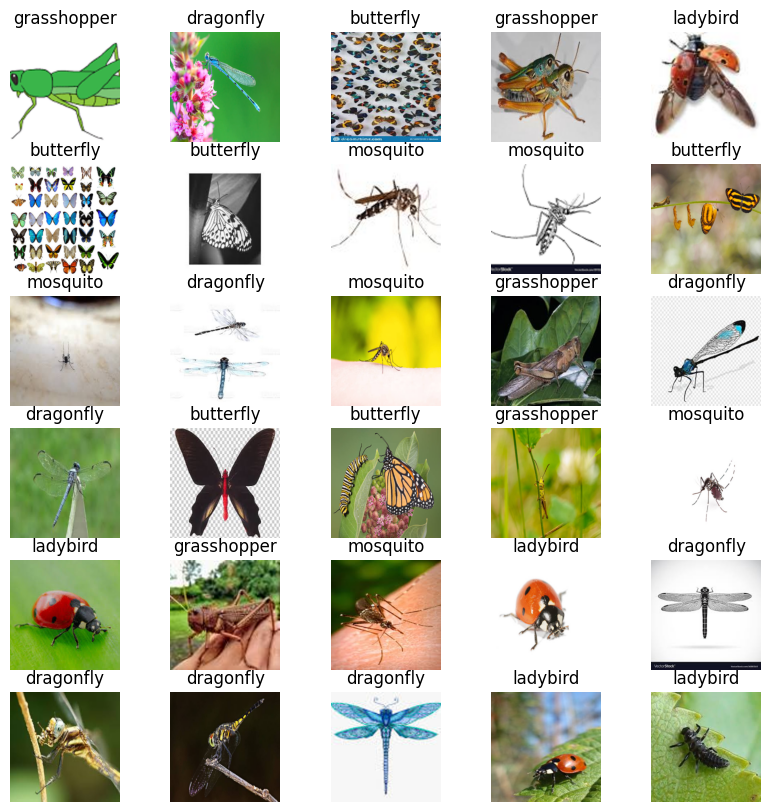

In [20]:
import matplotlib.pyplot as plt
axs = plt.figure(figsize=(10, 10)).subplots(6, 5)
axs = axs.flatten()
for i in range(30):
    n = np.random.randint(0, len(dataset))
    axs[i].imshow(dataset[n])
    axs[i].set_title(labels[n])
    axs[i].axis("off")


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    dataset, labels, test_size=0.2, random_state=42
)

In [ ]:
import torch
import cv2
import numpy as np
import requests
from PIL import Image
from torchvision import models, transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image



In [ ]:
# 3. Image Preprocessing Pipeline
def preprocess_image(img_path):
    rgb_img = np.float32(img_path) / 255
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224, 224)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # Create input tensor and ensure it's resized for the overlay later
    input_tensor = transform(img_path).unsqueeze(0)
    rgb_img_resized = cv2.resize(rgb_img, (224, 224))
    return input_tensor, rgb_img_resized

# 4. Run Grad-CAM
# Replace 'your_image.jpg' with your local file path
input_tensor, rgb_img = preprocess_image(dataset[40])  # Using the first image from the dataset for demonstration

RESNET152

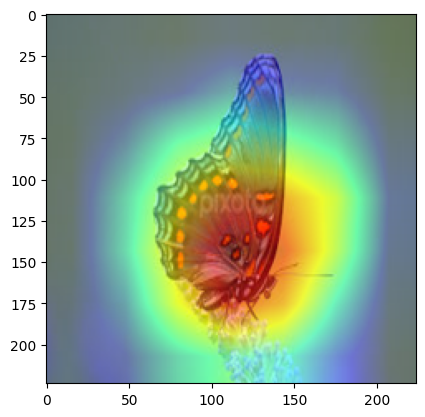

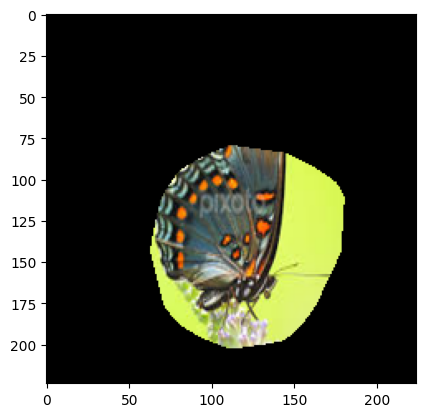

In [ ]:
# 1. Load a pre-trained ResNet-152 model
model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)
model.eval()

# 2. Target the last convolutional layer
# For ResNet-152, this is the very last bottleneck block
target_layers = [model.layer4[-1]]

# Gradient-weighted Class Activation Mapping (Grad-CAM) is a technique used to visualize the regions of an input
# image that are most important for a convolutional neural network's (CNN) decision-making process.
cam = GradCAM(model=model, target_layers=target_layers)

# If targets=None, it will show the CAM for the highest scoring category
# The output is a grayscale heatmap of shape [1, 224, 224] that can be overlaid on the original image
# and values are in the range [0, 1] where higher values indicate more important regions for the model's prediction.
grayscale_cam = cam(input_tensor=input_tensor, targets=None)  # You can specify a target class index if desired
mask = np.where(grayscale_cam> 0.5, 1, 0)[0]  # Thresholding the CAM for better visualization
# 5. Overlay and Save
# We take [0, :] because we only passed one image (batch size 1)
visualization = show_cam_on_image(rgb_img, grayscale_cam[0, :], use_rgb=True)
plt.imshow(visualization)
plt.show()
plt.imshow(rgb_img * mask.reshape(224, 224,1))  # Apply the mask to the original image

Vision Transformer

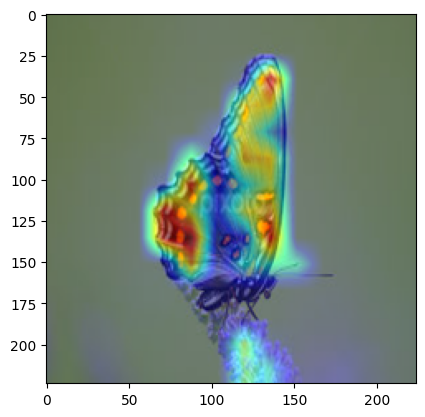

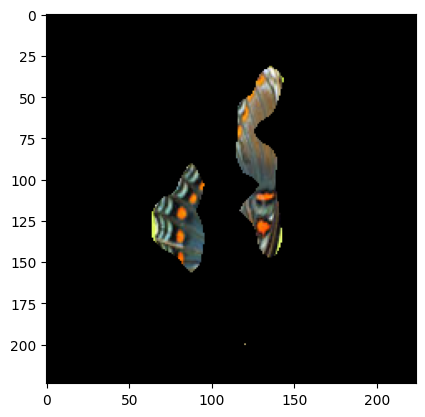

In [109]:
# 1. Define the Reshape Transform for ViT
def vit_reshape_transform(tensor, height=14, width=14):
    # The input 'tensor' has shape [Batch, Num_Tokens, Embedding_Dim]
    # For ViT-B/16, it is [1, 197, 768]
    
    # Discard the CLS token (the first one)
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))

    # Bring the channels to the second dimension for PyTorch compatibility
    # Shape becomes [Batch, Channels, Height, Width]
    result = result.permute(0, 3, 1, 2)
    return result

# 2. Load ViT Model
model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1).eval()

# 3. Target the last Norm layer in the last Transformer block
target_layers = [model.encoder.layers[-1].ln_1]

# 4. Initialize Grad-CAM with the reshape_transform
cam = GradCAM(model=model, 
             target_layers=target_layers, 
             reshape_transform=vit_reshape_transform)

# 5. Process Image
# (Assuming 'input_tensor' and 'rgb_img' are prepared as in previous steps)
grayscale_cam = cam(input_tensor=input_tensor, targets=None)
mask = np.where(grayscale_cam> 0.5, 1, 0)[0]  # Thresholding the CAM for better visualization
# 5. Overlay and Save
# We take [0, :] because we only passed one image (batch size 1)
visualization = show_cam_on_image(rgb_img, grayscale_cam[0, :], use_rgb=True)
plt.imshow(visualization)
plt.show()
plt.imshow(rgb_img * mask.reshape(224, 224,1))  # Apply the mask to the original image

Swin Transformer

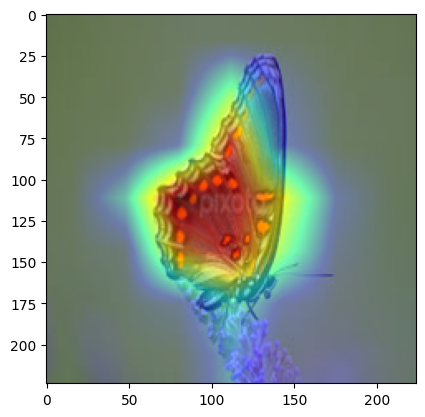

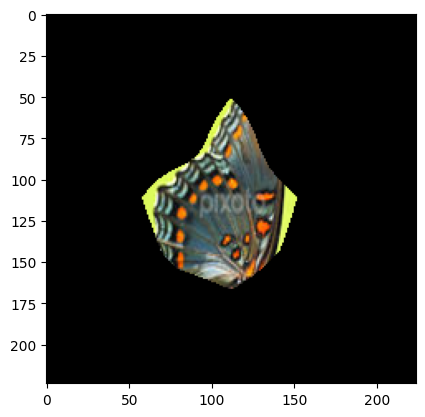

In [111]:
# 1. Load the pre-trained Swin Transformer
model = models.swin_b(weights=models.Swin_B_Weights.IMAGENET1K_V1).eval()

# 2. Define the Reshape Transform for Swin
def swin_reshape_transform(tensor, height=7, width=7):
    # tensor shape is [1, 49, 1024]
    # We want to reshape it to [1, 7, 7, 1024]
    
    # Use -1 for the channel dimension so it "auto-fills" the 1024
    result = tensor.reshape(tensor.size(0), height, width, -1)
    
    # Now move channels to the front for Grad-CAM: [1, 1024, 7, 7]
    result = result.permute(0, 3, 1, 2)
    return result

# 3. Select the target layer
# We target the very last layer of the feature extractor
target_layers = [model.features[-1]]

# 4. Initialize Grad-CAM
cam = GradCAM(model=model, 
             target_layers=target_layers, 
             reshape_transform=swin_reshape_transform)

# 5. Run the CAM
# (Assuming input_tensor is already on .cuda())
grayscale_cam = cam(input_tensor=input_tensor, targets=None)
mask = np.where(grayscale_cam> 0.5, 1, 0)[0]  # Thresholding the CAM for better visualization
# 5. Overlay and Save
# We take [0, :] because we only passed one image (batch size 1)
visualization = show_cam_on_image(rgb_img, grayscale_cam[0, :], use_rgb=True)
plt.imshow(visualization)
plt.show()
plt.imshow(rgb_img * mask.reshape(224, 224,1))  # Apply the mask to the original image